# 1. Entendimiento del problema
El gobierno Australiano quiere conocer cuanto puede ser el costo de el uso de corticoides y esteroides en el sistema de salud actual para preparar sus finanzas a futuro.

# 2. Enfoque analitico:
Vamos a construir un modelo de regresion basado en series de tiempo que permita estimar el costo de corticoides y esteroides con el menor MAE posible.  

# 3. Requerimiento de datos:
Se requiere los datos pasados del costo de los medicamentos.

# 4. Recolección de datos:

In [3]:
import matplotlib.pyplot as plt
from skforecast.datasets import fetch_dataset

In [4]:
data = fetch_dataset(name='wikipedia_visits')
data.index.name = 'datetime'

╭──────────────────────────────── wikipedia_visits ────────────────────────────────╮
│ Description:                                                                     │
│ Log daily page views for the Wikipedia page for Peyton Manning. Scraped data     │
│ using the Wikipediatrend package in R.                                           │
│                                                                                  │
│ Source:                                                                          │
│ https://github.com/facebook/prophet/blob/{version}/examples/example_wp_log_peyto │
│ n_manning.csv                                                                    │
│                                                                                  │
│ URL:                                                                             │
│ https://raw.githubusercontent.com/skforecast/skforecast-                         │
│ datasets/main/data/wikipedia_visits.csv                                          │
│                                                                                  │
│ Shape: 2964 rows x 1 columns                                                     │
╰──────────────────────────────────────────────────────────────────────────────────╯

In [5]:
print(f"Forma del dataset: {data.shape}")
print(f"Período: {data.index.min()} a {data.index.max()}")
print(f"Valores nulos: {data['y'].isna().sum()}")
data.head()

Forma del dataset: (2964, 1)
Período: 2007-12-10 00:00:00 a 2016-01-20 00:00:00
Valores nulos: 59


,y
datetime,
2007-12-10,9.590761
2007-12-11,8.519590
2007-12-12,8.183677
2007-12-13,8.072467
2007-12-14,7.893572


# 5. Exploracion de datos
- Imputacion datos nulos
- Determinar la estacionaridad de la serie

## Imputacion datos nulos

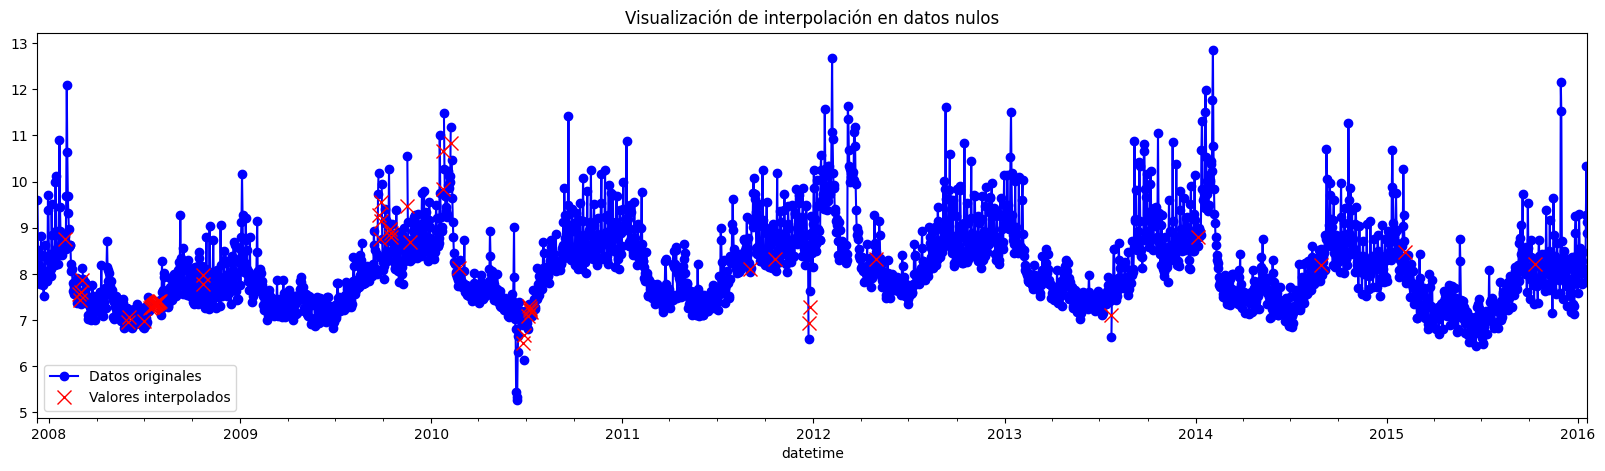

Valores nulos antes: 59
Valores nulos después de interpolación: 0
Forma del dataset: (2964, 1)


,y
datetime,
2007-12-10,9.590761
2007-12-11,8.519590
2007-12-12,8.183677
2007-12-13,8.072467
2007-12-14,7.893572


In [6]:
# Crear dataset sin valores nulos usando interpolación lineal
data_sin_nulos = data.copy()
mask_nulos = data_sin_nulos['y'].isna()
data_sin_nulos['y'] = data_sin_nulos['y'].interpolate(method='linear')

# Visualización de la interpolación
plt.figure(figsize=(20, 5))
data['y'].plot(marker='o', label='Datos originales', color='blue')
data_sin_nulos['y'][mask_nulos].plot(marker='x', ls='', color='red', markersize=10, label='Valores interpolados')
plt.legend()
plt.title('Visualización de interpolación en datos nulos')
plt.show()

# Verificar que ya no hay nulos
print(f"Valores nulos antes: {data['y'].isna().sum()}")
print(f"Valores nulos después de interpolación: {data_sin_nulos['y'].isna().sum()}")
print(f"Forma del dataset: {data_sin_nulos.shape}")
data_sin_nulos.head()

## Determinar la estacionaridad de la serie

In [7]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from skforecast.plot import set_dark_theme

set_dark_theme()

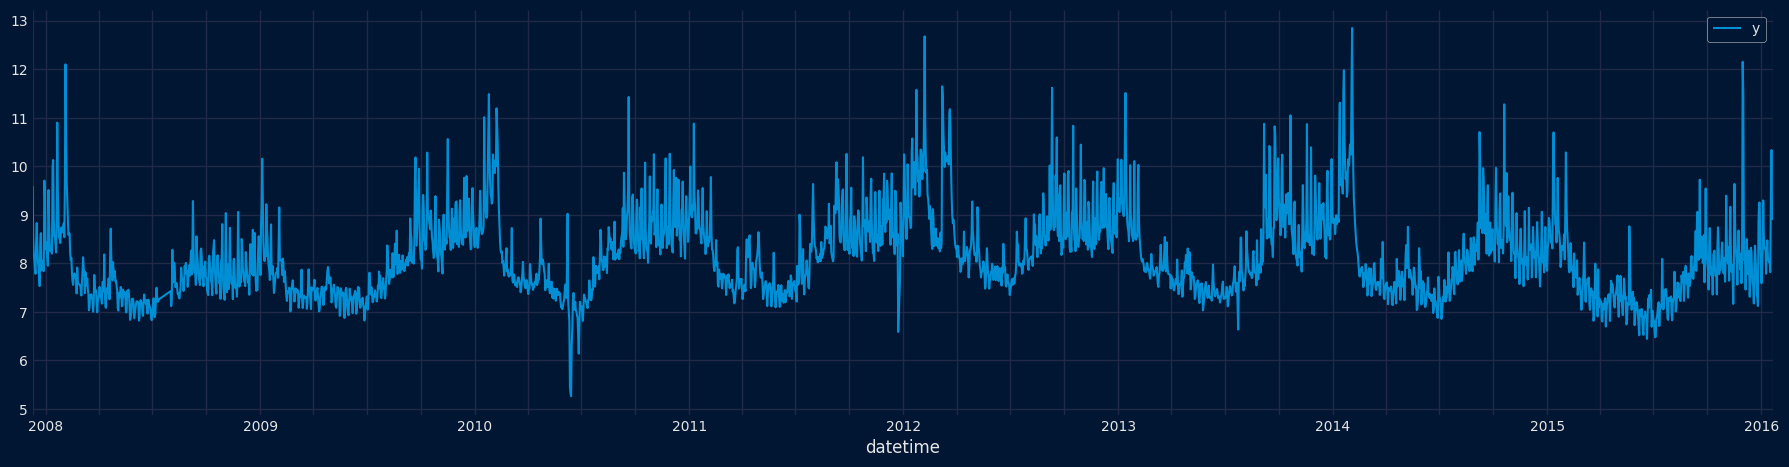

In [8]:
fig, ax = plt.subplots(figsize=(20, 5))
data_sin_nulos.plot(ax=ax)
plt.show()

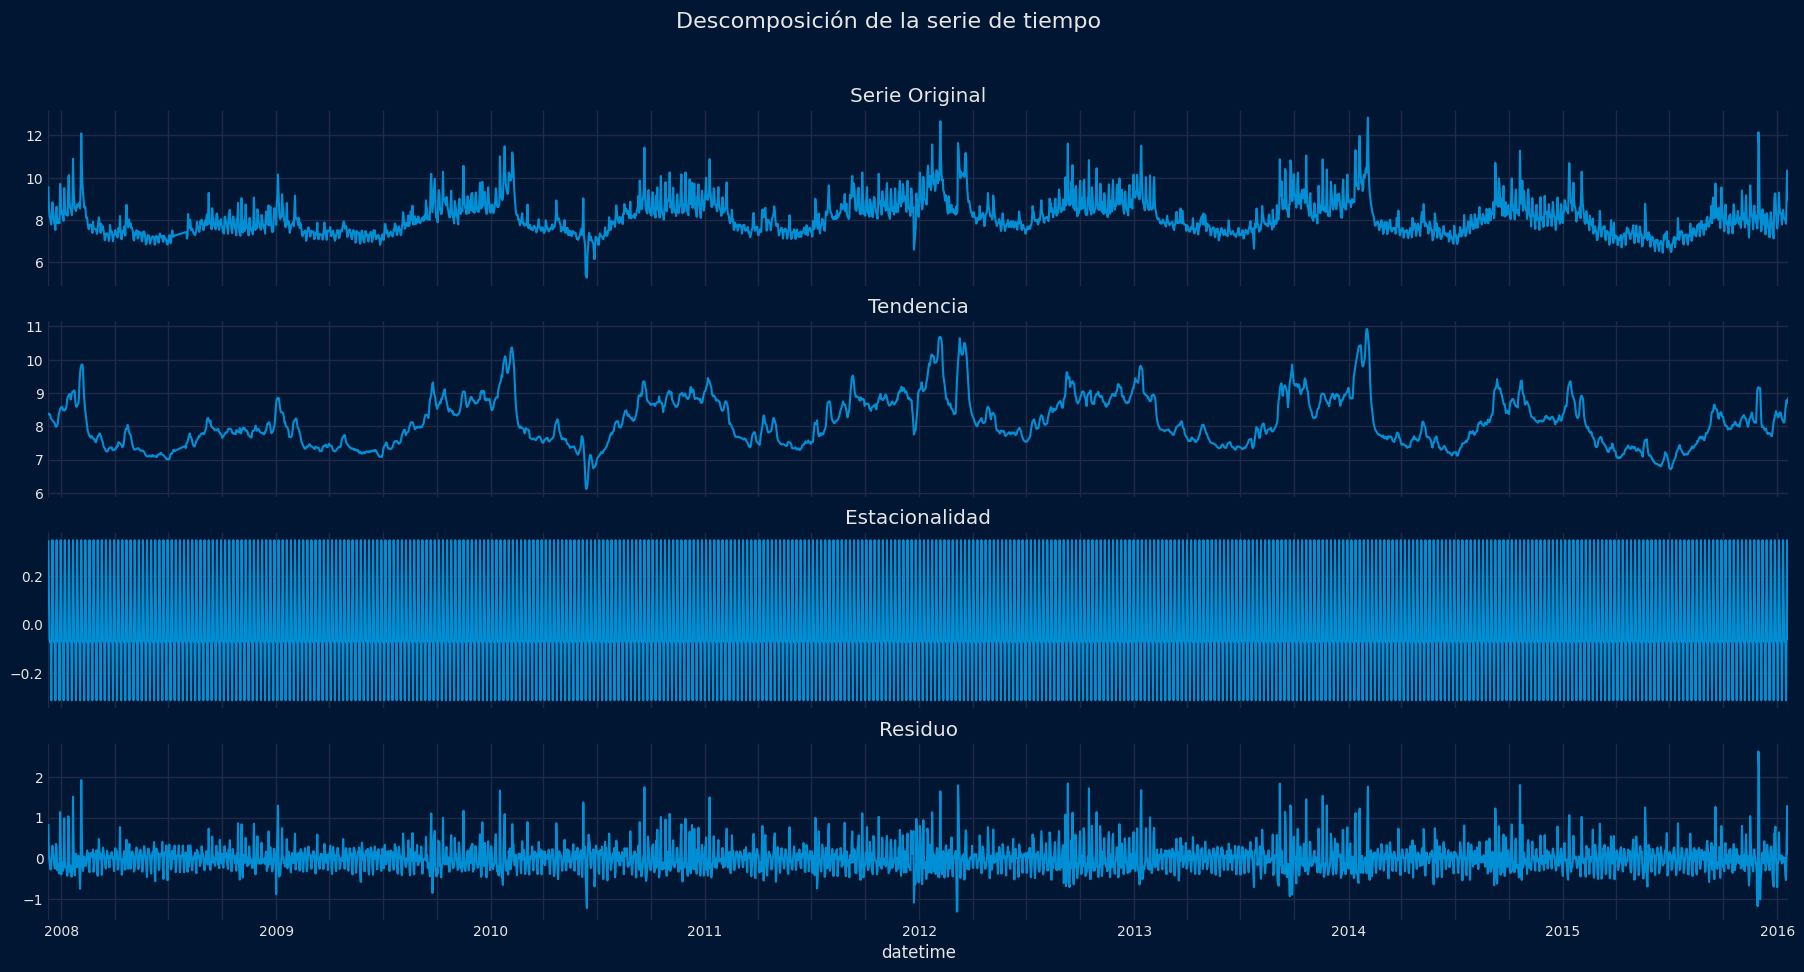

In [31]:
res_decompose = seasonal_decompose(data_sin_nulos['y'], extrapolate_trend='freq')
fig, ax = plt.subplots(4, 1, figsize=(20, 10), sharex=True)

res_decompose.observed.plot(ax=ax[0])
ax[0].set_title('Serie Original')

res_decompose.trend.plot(ax=ax[1])
ax[1].set_title('Tendencia')

res_decompose.seasonal.plot(ax=ax[2])
ax[2].set_title('Estacionalidad')

res_decompose.resid.plot(ax=ax[3])
ax[3].set_title('Residuo')

fig.suptitle('Descomposición de la serie de tiempo', fontsize=16)
plt.show()

In [10]:
def test_estacionaridad(series):
    adfuller_result = adfuller(series)
    print(f'ADF Estadistico: {adfuller_result[0]}')
    print(f'Valor p: {adfuller_result[1]}')

In [11]:
test_estacionaridad(data_sin_nulos['y'])

ADF Estadistico: -4.570400981802579
Valor p: 0.00014640608764999698


# 6. Preparacion de datos

- Diferenciar la serie
- Identificar su comportamiento estacional

ADF Estadistico: -12.71356361111104
Valor p: 1.0178418031629535e-23


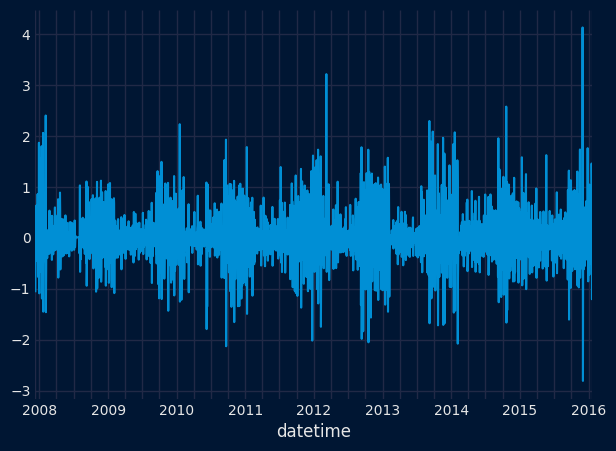

In [12]:
data_diff = data_sin_nulos['y'].diff().dropna()
test_estacionaridad(data_diff)
data_diff.plot()
plt.show()

## Obtener valor q

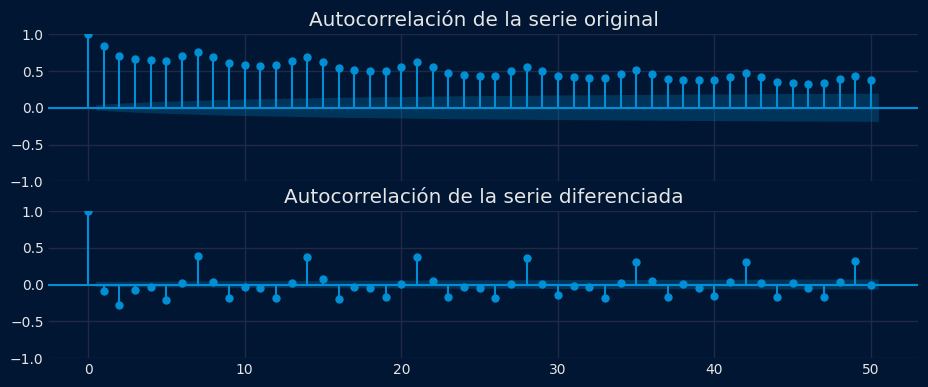

In [13]:
from statsmodels.graphics.tsaplots import plot_acf

# Grafico de autocorrelacion
fig, ax = plt.subplots(2, 1, figsize=(10, 4), sharex=True)

plot_acf(data_sin_nulos['y'], ax=ax[0], lags=50, alpha=0.05)
ax[0].set_title('Autocorrelación de la serie original')

plot_acf(data_diff, ax=ax[1], lags=50, alpha=0.05)
ax[1].set_title('Autocorrelación de la serie diferenciada')

plt.show()

In [14]:
value_q = 3

## Obtener valor p

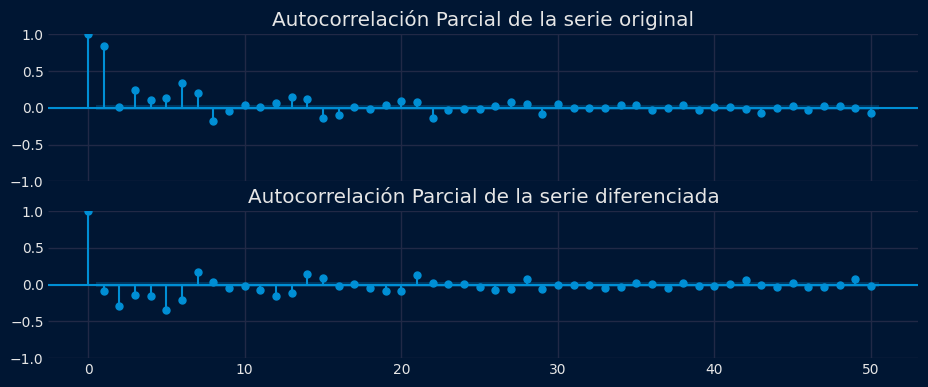

In [15]:
from statsmodels.graphics.tsaplots import plot_pacf

# Grafico de autocorrelacion
fig, ax = plt.subplots(2, 1, figsize=(10, 4), sharex=True)

plot_pacf(data_sin_nulos['y'], ax=ax[0], lags=50, alpha=0.05)
ax[0].set_title('Autocorrelación Parcial de la serie original')

plot_pacf(data_diff, ax=ax[1], lags=50, alpha=0.05)
ax[1].set_title('Autocorrelación Parcial de la serie diferenciada')

plt.show()

In [16]:
value_p = 3

## Separacion datos entrenamiento y prueba

end_train: 2013-08-13 00:00:00


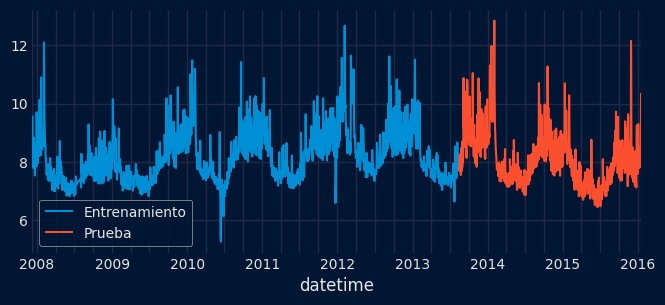

In [17]:
train_size = int(len(data_sin_nulos) * 0.7)
end_train = data_sin_nulos.index[train_size - 1]
print(f'end_train: {end_train}')

data_train = data_sin_nulos['y'].loc[:end_train]
data_test = data_sin_nulos['y'].loc[end_train:]

plt.figure(figsize=(7, 3))
data_train.plot(label='Entrenamiento')
data_test.plot(label='Prueba')
plt.legend()
plt.show()

# 7. Modelado
- SARIMAX
- Forecaster
- RNA Secuencial

## SARIMAX

In [18]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

modelo_sarimax = SARIMAX(data_train, order=(value_p, 1, value_q))
modelo_sarimax_fit = modelo_sarimax.fit(disp = 0)
modelo_sarimax_fit.summary()

c:\Users\DELL\Documents\DAVID\Universidad\Semestre 8\ComputacionCientifica\compCientEnv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 2074
Model:               SARIMAX(3, 1, 3)   Log Likelihood                -974.289
Date:                Mon, 27 Oct 2025   AIC                           1962.578
Time:                        08:07:31   BIC                           2002.035
Sample:                    12-10-2007   HQIC                          1977.040
                         - 08-13-2013                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.6087      0.033     48.686      0.000       1.544       1.673
ar.L2         -1.4463      0.042    -34.602      0.000      -1.528      -1.364
ar.L3          0.3663      0.032     11.375      0.000       0.303       0.429
ma.L1         -1.9836      0.028    -70.393      0.000      -2.039      -1.928
ma.L2          1.8666      0.039     47.927      0.000       1.790       1.943
ma.L3         -0.7412      0.026    -28.923      0.000      -0.791      -0.691
sigma2         0.1497      0.002     63.146      0.000       0.145       0.154
===================================================================================
Ljung-Box (L1) (Q):                   0.82   Jarque-Bera (JB):              4216.40
Prob(Q):                              0.36   Prob(JB):                         0.00
Heteroskedasticity (H):               1.73   Skew:                             1.15
Prob(H) (two-sided):                  0.00   Kurtosis:                         9.60
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [19]:
pred_sarimax = modelo_sarimax_fit.get_forecast(steps=len(data_test)).predicted_mean
pred_sarimax.name = 'predicciones_sarimax'
display(pred_sarimax.head(4))

2013-08-14    7.886267
2013-08-15    7.908664
2013-08-16    7.884669
2013-08-17    7.853712
Freq: D, Name: predicciones_sarimax, dtype: float64

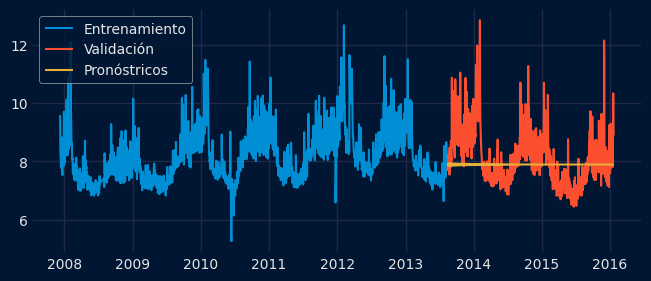

In [20]:
plt.figure(figsize=(7, 3))
plt.plot(data_train, label='Entrenamiento')
plt.plot(data_test, label='Validación')
plt.plot(pred_sarimax, label='Pronóstricos')
plt.legend()
plt.show()

In [21]:
from sklearn.metrics import mean_absolute_percentage_error

mape_sarimax = mean_absolute_percentage_error(data_test, pred_sarimax)
print(f'MAPE: {mape_sarimax}')

MAPE: 0.0785832486372768


## Series de tiempo con ML

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from skforecast.recursive import ForecasterRecursive
from skforecast.preprocessing import RollingFeatures
from skforecast.plot import plot_prediction_intervals

c:\Users\DELL\Documents\DAVID\Universidad\Semestre 8\ComputacionCientifica\compCientEnv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Forecaster 1 (RandomForestRegressor)

In [23]:
forecaster_1 = ForecasterRecursive(
  regressor=RandomForestRegressor(),
  lags=15,
  window_features=RollingFeatures(stats=['mean'], window_sizes=10)
)

forecaster_1.fit(y=data_train, store_in_sample_residuals=True)
forecaster_1

=================== 
ForecasterRecursive 
=================== 
Regressor: RandomForestRegressor 
Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15] 
Window features: ['roll_mean_10'] 
Window size: 15 
Series name: y 
Exogenous included: False 
Exogenous names: None 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: [Timestamp('2007-12-10 00:00:00'), Timestamp('2013-08-13 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: D 
Regressor parameters: 
    {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth':
    None, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None,
    'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2,
    'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100,
    'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0,
    'warm_start': False} 
fit_kwargs: {} 
Creation date: 2025-10-27 08:07:34 
Last fit date: 2025-10-27 08:07:37 
Skforecast version: 0.18.0 
Python version: 3.12.6 
Forecaster id: None

In [24]:
predictions_1 = forecaster_1.predict(steps=len(data_test))
predictions_1

2013-08-14    7.743284
2013-08-15    7.649642
2013-08-16    7.726814
2013-08-17    7.744438
2013-08-18    7.709653
                ...   
2016-01-17    7.621822
2016-01-18    7.642684
2016-01-19    7.619414
2016-01-20    7.615529
2016-01-21    7.653707
Freq: D, Name: pred, Length: 891, dtype: float64

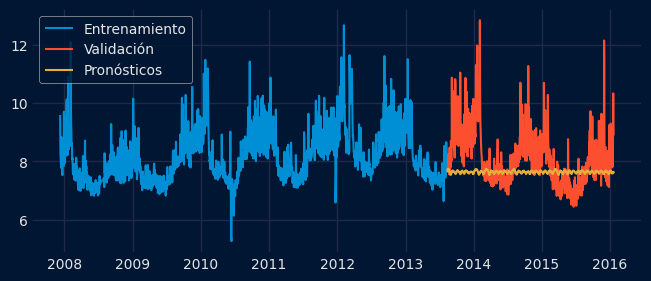

In [25]:
plt.figure(figsize=(7, 3))
plt.plot(data_train, label='Entrenamiento')
plt.plot(data_test, label='Validación')
plt.plot(predictions_1, label='Pronósticos')
plt.legend()
plt.show()

In [26]:
mape_forecaster_1 = mean_absolute_percentage_error(data_test, predictions_1)
mape_forecaster_1

0.08285514833043683

In [27]:
predictions_1_interval = forecaster_1.predict_interval(
    steps=len(data_test)-1,
    interval=[5, 95],
    method='bootstrapping',
    n_boot=100
)

plot_prediction_intervals(
  predictions=predictions_1_interval,
  y_true=data_test,
  target_variable='y',
  kwargs_fill_between={'color':'yellow', 'alpha':0.3},
)

plt.show()

KeyboardInterrupt: 

### Forecaster 2 (DecisionTreeRegressor)

In [ ]:
forecaster_2 = ForecasterRecursive(
  regressor=DecisionTreeRegressor(random_state=42),
  lags=15,
  window_features=RollingFeatures(stats=['mean'], window_sizes=10)
)

forecaster_2.fit(y=data_train, store_in_sample_residuals=True)
forecaster_2

=================== 
ForecasterRecursive 
=================== 
Regressor: DecisionTreeRegressor 
Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15] 
Window features: ['roll_mean_10'] 
Window size: 15 
Series name: y 
Exogenous included: False 
Exogenous names: None 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: [Timestamp('2007-12-10 00:00:00'), Timestamp('2013-08-13 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: D 
Regressor parameters: 
    {'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None,
    'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0,
    'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf':
    0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'} 
fit_kwargs: {} 
Creation date: 2025-10-26 19:06:06 
Last fit date: 2025-10-26 19:06:06 
Skforecast version: 0.18.0 
Python version: 3.12.6 
Forecaster id: None

In [ ]:
predictions_2 = forecaster_2.predict(steps=len(data_test))
predictions_2

2013-08-14    7.812378
2013-08-15    7.803027
2013-08-16    7.786967
2013-08-17    8.053251
2013-08-18    8.259976
                ...   
2016-01-17    8.283999
2016-01-18    8.390723
2016-01-19    8.536407
2016-01-20    8.605387
2016-01-21    8.536407
Freq: D, Name: pred, Length: 891, dtype: float64

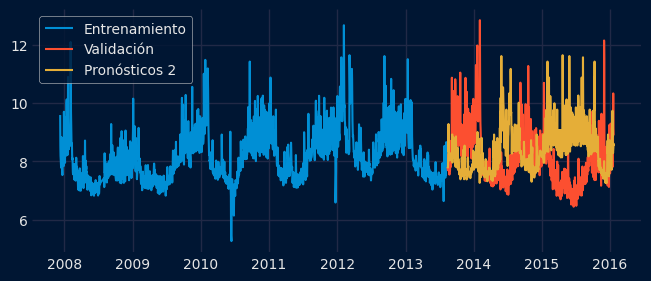

In [ ]:
plt.figure(figsize=(7, 3))
plt.plot(data_train, label='Entrenamiento')
plt.plot(data_test, label='Validación')
plt.plot(predictions_2, label='Pronósticos 2')
plt.legend()
plt.show()

In [ ]:
mape_forecaster_2 = mean_absolute_percentage_error(data_test, predictions_2)
mape_forecaster_2

0.13535040680003824

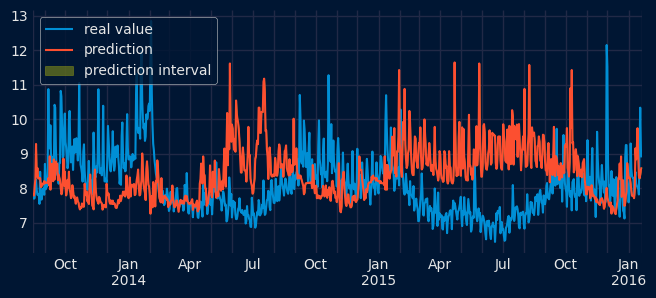

In [ ]:
predictions_2_interval = forecaster_2.predict_interval(
    steps=len(data_test)-1,
    interval=[5, 95],
    method='bootstrapping',
    n_boot=100
)

plot_prediction_intervals(
  predictions=predictions_2_interval,
  y_true=data_test,
  target_variable='y',
  kwargs_fill_between={'color':'yellow', 'alpha':0.3},
)

plt.show()

### Forecaster 3 (DecisionTreeRegressor mejorado)

In [ ]:
from skforecast.model_selection import grid_search_forecaster, random_search_forecaster, TimeSeriesFold

In [ ]:
forecaster_3 = ForecasterRecursive(
  regressor=DecisionTreeRegressor(random_state=42),
  lags=10,
)

# Busqueda de la ventana
lags_grid = {
  'lags_1': 3,
  'lags_2': 10,
  'lags_3': [1, 2, 3, 12],
}

# Busqueda de hiperparametros del regresor
param_grid = {
  'max_depth': [5, 10, 20],
  'criterion': ['squared_error', 'poisson', 'absolute_error', 'friedman_mse'],
}

# Folds
cv = TimeSeriesFold(
  steps=12,
  initial_train_size=len(data_test),
  refit=False
)

# Implementacion de la busqueda
results = grid_search_forecaster(
  forecaster=forecaster_3,
  y=data_train,
  param_grid=param_grid,
  lags_grid=lags_grid,
  cv=cv,
  metric='mean_squared_error',
  return_best=True,
  verbose=False,
  n_jobs=-1,
  show_progress=True
)
results

lags grid: 100%|██████████| 3/3 [00:16<00:00,  5.52s/it]

`Forecaster` refitted using the best-found lags and parameters, and the whole data set: 
  Lags: [ 1  2  3 12] 
  Parameters: {'criterion': 'squared_error', 'max_depth': 5}
  Backtesting metric: 0.4271265609703878


,lags,lags_label,params,mean_squared_error,criterion,max_depth
0,"[1, 2, 3, 12]",lags_3,"{'criterion': 'squared_error', 'max_depth': 5}",0.427127,squared_error,5
1,"[1, 2, 3, 12]",lags_3,"{'criterion': 'poisson', 'max_depth': 5}",0.427127,poisson,5
2,"[1, 2, 3, 12]",lags_3,"{'criterion': 'friedman_mse', 'max_depth': 5}",0.427127,friedman_mse,5
3,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",lags_2,"{'criterion': 'poisson', 'max_depth': 5}",0.430918,poisson,5
4,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",lags_2,"{'criterion': 'friedman_mse', 'max_depth': 5}",0.435353,friedman_mse,5
5,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",lags_2,"{'criterion': 'squared_error', 'max_depth': 5}",0.435353,squared_error,5
6,"[1, 2, 3, 12]",lags_3,"{'criterion': 'absolute_error', 'max_depth': 5}",0.439501,absolute_error,5
7,"[1, 2, 3]",lags_1,"{'criterion': 'poisson', 'max_depth': 5}",0.458854,poisson,5
8,"[1, 2, 3]",lags_1,"{'criterion': 'friedman_mse', 'max_depth': 5}",0.458971,friedman_mse,5
9,"[1, 2, 3]",lags_1,"{'criterion': 'squared_error', 'max_depth': 5}",0.458971,squared_error,5


In [ ]:
forecaster_3

=================== 
ForecasterRecursive 
=================== 
Regressor: DecisionTreeRegressor 
Lags: [ 1  2  3 12] 
Window features: None 
Window size: 12 
Series name: y 
Exogenous included: False 
Exogenous names: None 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: [Timestamp('2007-12-10 00:00:00'), Timestamp('2013-08-13 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: D 
Regressor parameters: 
    {'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': 5, 'max_features':
    None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0,
    'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf':
    0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'} 
fit_kwargs: {} 
Creation date: 2025-10-26 19:06:16 
Last fit date: 2025-10-26 19:06:33 
Skforecast version: 0.18.0 
Python version: 3.12.6 
Forecaster id: None

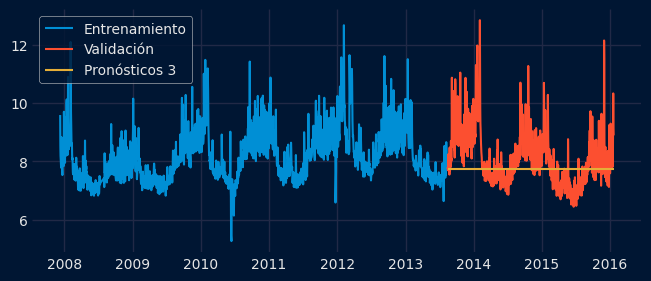

In [ ]:
predictions_3 = forecaster_3.predict(steps=len(data_test))

plt.figure(figsize=(7, 3))
plt.plot(data_train, label='Entrenamiento')
plt.plot(data_test, label='Validación')
plt.plot(predictions_3, label='Pronósticos 3')
plt.legend()
plt.show()

In [ ]:
mape_forecaster_3 = mean_absolute_percentage_error(data_test, predictions_3)
mape_forecaster_3

0.08005319833435726

### Forecaster 4 (RandomForestRegressor mejorado)

In [ ]:
forecaster_4 = ForecasterRecursive(
  regressor=RandomForestRegressor(random_state=42),
  lags=10,
)

# Busqueda de la ventana
lags_grid = {
  'lags_1': 3,
  'lags_2': 10,
  'lags_3': [1, 2, 3, 12],
}

# Busqueda de hiperparametros del regresor
param_grid = {
  'max_depth': [5, 10, 20],
  'criterion': ['squared_error', 'poisson', 'absolute_error', 'friedman_mse'],
  'n_estimators': [100, 200, 300]
}

# Folds
cv = TimeSeriesFold(
  steps=12,
  initial_train_size=len(data_test),
  refit=False
)

# Implementacion de la busqueda
results = grid_search_forecaster(
  forecaster=forecaster_4,
  y=data_train,
  param_grid=param_grid,
  lags_grid=lags_grid,
  cv=cv,
  metric='mean_squared_error',
  return_best=True,
  verbose=False,
  n_jobs=-1,
  show_progress=True
)
results

lags grid:  67%|██████▋   | 2/3 [08:51<04:28, 268.47s/it]c:\Users\DELL\Documents\DAVID\Universidad\Semestre 8\ComputacionCientifica\compCientEnv\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
lags grid: 100%|██████████| 3/3 [26:30<00:00, 530.06s/it]


`Forecaster` refitted using the best-found lags and parameters, and the whole data set: 
  Lags: [ 1  2  3  4  5  6  7  8  9 10] 
  Parameters: {'criterion': 'absolute_error', 'max_depth': 5, 'n_estimators': 100}
  Backtesting metric: 0.3563508674443372


,lags,lags_label,params,mean_squared_error,criterion,max_depth,n_estimators
0,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",lags_2,"{'criterion': 'absolute_error', 'max_depth': 5...",0.356351,absolute_error,5,100
1,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",lags_2,"{'criterion': 'absolute_error', 'max_depth': 5...",0.359233,absolute_error,5,300
2,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",lags_2,"{'criterion': 'squared_error', 'max_depth': 5,...",0.361465,squared_error,5,100
3,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",lags_2,"{'criterion': 'friedman_mse', 'max_depth': 5, ...",0.361743,friedman_mse,5,100
4,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",lags_2,"{'criterion': 'poisson', 'max_depth': 5, 'n_es...",0.362083,poisson,5,200
...,...,...,...,...,...,...,...
103,"[1, 2, 3]",lags_1,"{'criterion': 'absolute_error', 'max_depth': 5...",0.463768,absolute_error,5,100
104,"[1, 2, 3]",lags_1,"{'criterion': 'absolute_error', 'max_depth': 5...",0.464205,absolute_error,5,300
105,"[1, 2, 3]",lags_1,"{'criterion': 'absolute_error', 'max_depth': 5...",0.468776,absolute_error,5,200
106,"[1, 2, 3]",lags_1,"{'criterion': 'poisson', 'max_depth': 20, 'n_e...",0.470516,poisson,20,100


In [ ]:
forecaster_4

=================== 
ForecasterRecursive 
=================== 
Regressor: RandomForestRegressor 
Lags: [ 1  2  3  4  5  6  7  8  9 10] 
Window features: None 
Window size: 10 
Series name: y 
Exogenous included: False 
Exogenous names: None 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: [Timestamp('2007-12-10 00:00:00'), Timestamp('2013-08-13 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: D 
Regressor parameters: 
    {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'absolute_error',
    'max_depth': 5, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples':
    None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1,
    'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst':
    None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False,
    'random_state': 42, 'verbose': 0, 'warm_start': False} 
fit_kwargs: {} 
Creation date: 2025-10-26 19:06:33 
Last fit date: 2025-10-26 19:33:10 
Skforecast version: 0.18.0 
Python version: 3.12.6 
Forecaster id: None

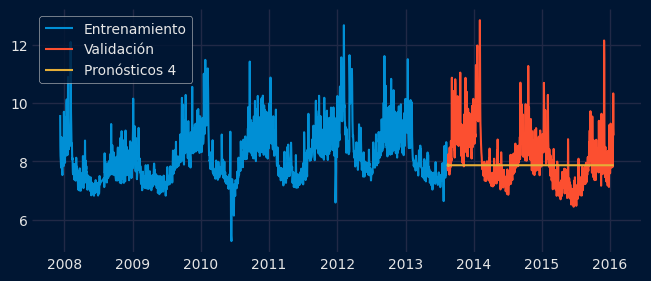

In [ ]:
predictions_4 = forecaster_4.predict(steps=len(data_test))

plt.figure(figsize=(7, 3))
plt.plot(data_train, label='Entrenamiento')
plt.plot(data_test, label='Validación')
plt.plot(predictions_4, label='Pronósticos 4')
plt.legend()
plt.show()

In [ ]:
mape_forecaster_4 = mean_absolute_percentage_error(data_test, predictions_4)
mape_forecaster_4

0.0786133207242763

## Redes Neuronales Artificiales

In [ ]:
from skforecast.deep_learning import ForecasterRnn, create_and_compile_model
from keras.optimizers import Adam
from keras.losses import MeanSquaredError
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
import pandas as pd

In [ ]:
model_rna = create_and_compile_model(
  series = pd.DataFrame(data_train),
  levels = ['y'],
  lags = 24,
  steps = 1,
  recurrent_layer = 'RNN',
  recurrent_units = 100,
  dense_units = 64
)

model_rna.summary()

keras version: 3.11.3
Using backend: tensorflow
tensorflow version: 2.20.0



Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ series_input (InputLayer)       │ (None, 24, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_1 (SimpleRNN)               │ (None, 100)            │        10,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_dense_td_layer (Dense)   │ (None, 1)              │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 1, 1)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,729 (65.35 KB)

 Trainable params: 16,729 (65.35 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
forecaster_5 = ForecasterRnn(
  regressor = model_rna,
  levels = ['y'],
  lags = 24,
  transformer_series = MinMaxScaler(),
  fit_kwargs = {
    'epochs': 25,
    'batch_size': 512,
    'callbacks': [EarlyStopping(monitor='val_loss', restore_best_weights=True)],
    'series_val': pd.DataFrame(data_test)
  },
)

forecaster_5.fit(pd.DataFrame(data_train))

Epoch 1/25
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - loss: 0.1132 - val_loss: 0.0079
Epoch 2/25
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0101 - val_loss: 0.0080


In [ ]:
forecaster_5

============= 
ForecasterRnn 
============= 
Regressor: <Functional name=functional_1, built=True> 
Layers names: ['series_input', 'rnn_1', 'dense_1', 'output_dense_td_layer', 'reshape'] 
Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24] 
Window size: 24 
Maximum steps to predict: [1] 
Series names: y 
Target series (levels): ['y'] 
Exogenous included: False 
Exogenous names: None 
Transformer for series: MinMaxScaler() 
Transformer for exog: MinMaxScaler() 
Training range: [Timestamp('2007-12-10 00:00:00'), Timestamp('2013-08-13 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: D 
Regressor parameters: {'name': 'functional_1', 'trainable': True, 'layers': [{'module': 'keras.layers', 'class_name': 'InputLayer', 'config': {'batch_shape': (None, 24, 1), 'dtype': 'float32', 'sparse': False, 'ragged': False, 'name': 'series_input'}, 'registered_name': None, 'name': 'series_input', 'inbound_nodes': []}, {'module': 'keras.layers', 'class_name': 'SimpleRNN', 'config': {'name': 'rnn_1', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None}, 'return_sequences': False, 'return_state': False, 'go_backwards': False, 'stateful': False, 'unroll': False, 'zero_output_for_mask': False, 'units': 100, 'activation': 'tanh', 'use_bias': True, 'kernel_initializer': {'module': 'keras.initializers', 'class_name': 'GlorotUniform', 'config': {'seed': None}, 'registered_name': None}, 'recurrent_initializer': {'module': 'keras.initializers', 'class_name': 'Orthogonal', 'config': {'seed': None, 'gain': 1.0}, 'registered_name': None}, 'bias_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'kernel_regularizer': None, 'recurrent_regularizer': None, 'bias_regularizer': None, 'activity_regularizer': None, 'kernel_constraint': None, 'recurrent_constraint': None, 'bias_constraint': None, 'dropout': 0.0, 'recurrent_dropout': 0.0}, 'registered_name': None, 'build_config': {'input_shape': [None, 24, 1]}, 'name': 'rnn_1', 'inbound_nodes': [{'args': ({'class_name': '__keras_tensor__', 'config': {'shape': (None, 24, 1), 'dtype': 'float32', 'keras_history': ['series_input', 0, 0]}},), 'kwargs': {'training': False, 'mask': None}}]}, {'module': 'keras.layers', 'class_name': 'Dense', 'config': {'name': 'dense_1', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None}, 'units': 64, 'activation': 'relu', 'use_bias': True, 'kernel_initializer': {'module': 'keras.initializers', 'class_name': 'GlorotUniform', 'config': {'seed': None}, 'registered_name': None}, 'bias_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'kernel_regularizer': None, 'bias_regularizer': None, 'kernel_constraint': None, 'bias_constraint': None}, 'registered_name': None, 'build_config': {'input_shape': [None, 100]}, 'name': 'dense_1', 'inbound_nodes': [{'args': ({'class_name': '__keras_tensor__', 'config': {'shape': (None, 100), 'dtype': 'float32', 'keras_history': ['rnn_1', 0, 0]}},), 'kwargs': {}}]}, {'module': 'keras.layers', 'class_name': 'Dense', 'config': {'name': 'output_dense_td_layer', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None}, 'units': 1, 'activation': 'linear', 'use_bias': True, 'kernel_initializer': {'module': 'keras.initializers', 'class_name': 'GlorotUniform', 'config': {'seed': None}, 'registered_name': None}, 'bias_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'kernel_regularizer': None, 'bias_regularizer': None, 'kernel_constraint': None, 'bias_constraint': None}, 'registered_name': None, 'build_config': {'input_shape': [None, 64]}, 'name': 'output_dense_td_layer', 'inbound_nodes': [{'args': ({'class_name':

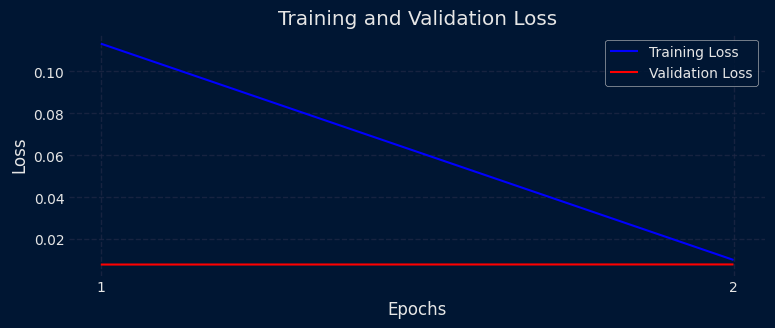

In [ ]:
fig, ax = plt.subplots(figsize = (8,3))
plot = forecaster_5.plot_history(ax = ax)

In [ ]:
from skforecast.model_selection import backtesting_forecaster_multiseries
cv = TimeSeriesFold(
  steps=forecaster_5.max_step,
  initial_train_size=len(data_test),
  refit=False
)

metrics, predictions_5 = backtesting_forecaster_multiseries(
  forecaster=forecaster_5,
  series = pd.DataFrame(data_train),
  cv=cv,
  levels = forecaster_5.levels,
  metric='mean_squared_error',
  verbose=False
)

Epoch 1/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 296ms/step - loss: 0.0071 - val_loss: 0.0131
Epoch 2/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - loss: 0.0079 - val_loss: 0.0153


100%|██████████| 1183/1183 [01:42<00:00, 11.58it/s]


In [ ]:
mape_forecaster_5 = metrics['mean_squared_error']
mape_forecaster_5

0    0.35164
Name: mean_squared_error, dtype: float64

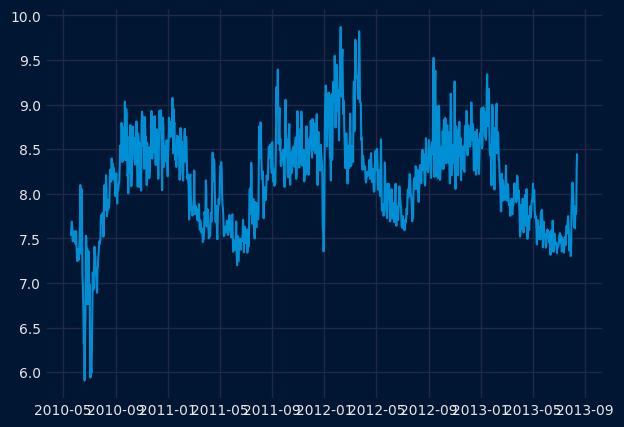

In [ ]:
plt.plot(predictions_5['pred'])

# 8. Evaluación y Comparación de Modelos

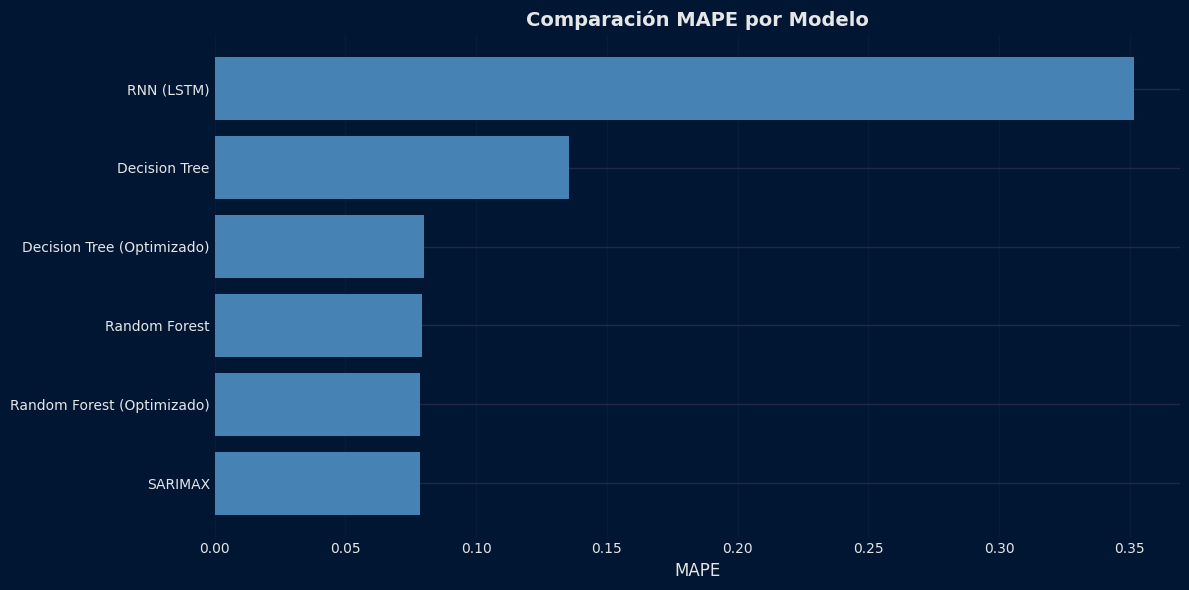


Resultados de MAPE por Modelo:
                    Modelo     MAPE
                   SARIMAX 0.078583
Random Forest (Optimizado) 0.078613
             Random Forest 0.079398
Decision Tree (Optimizado) 0.080053
             Decision Tree 0.135350
                RNN (LSTM) 0.351640

Mejor modelo: SARIMAX con MAPE = 0.0786


In [ ]:
# Crear DataFrame con los resultados MAPE
modelos_comparacion = pd.DataFrame({
    'Modelo': [
        'SARIMAX',
        'Random Forest',
        'Decision Tree',
        'Decision Tree (Optimizado)',
        'Random Forest (Optimizado)',
        'RNN (LSTM)'
    ],
    'MAPE': [
        mape_sarimax,
        mape_forecaster_1,
        mape_forecaster_2,
        mape_forecaster_3,
        mape_forecaster_4,
        mape_forecaster_5.iloc[0] if isinstance(mape_forecaster_5, pd.Series) else mape_forecaster_5
    ]
})

# Ordenar por MAPE de menor a mayor (mejor a peor)
modelos_comparacion = modelos_comparacion.sort_values('MAPE')

# Crear la gráfica de barras horizontales
plt.figure(figsize=(12, 6))
plt.barh(modelos_comparacion['Modelo'], modelos_comparacion['MAPE'], color='steelblue')
plt.xlabel('MAPE', fontsize=12)
plt.title('Comparación MAPE por Modelo', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Mostrar tabla de resultados
print("\nResultados de MAPE por Modelo:")
print(modelos_comparacion.to_string(index=False))
print(f"\nMejor modelo: {modelos_comparacion.iloc[0]['Modelo']} con MAPE = {modelos_comparacion.iloc[0]['MAPE']:.4f}")

## Comparación Visual de Predicciones

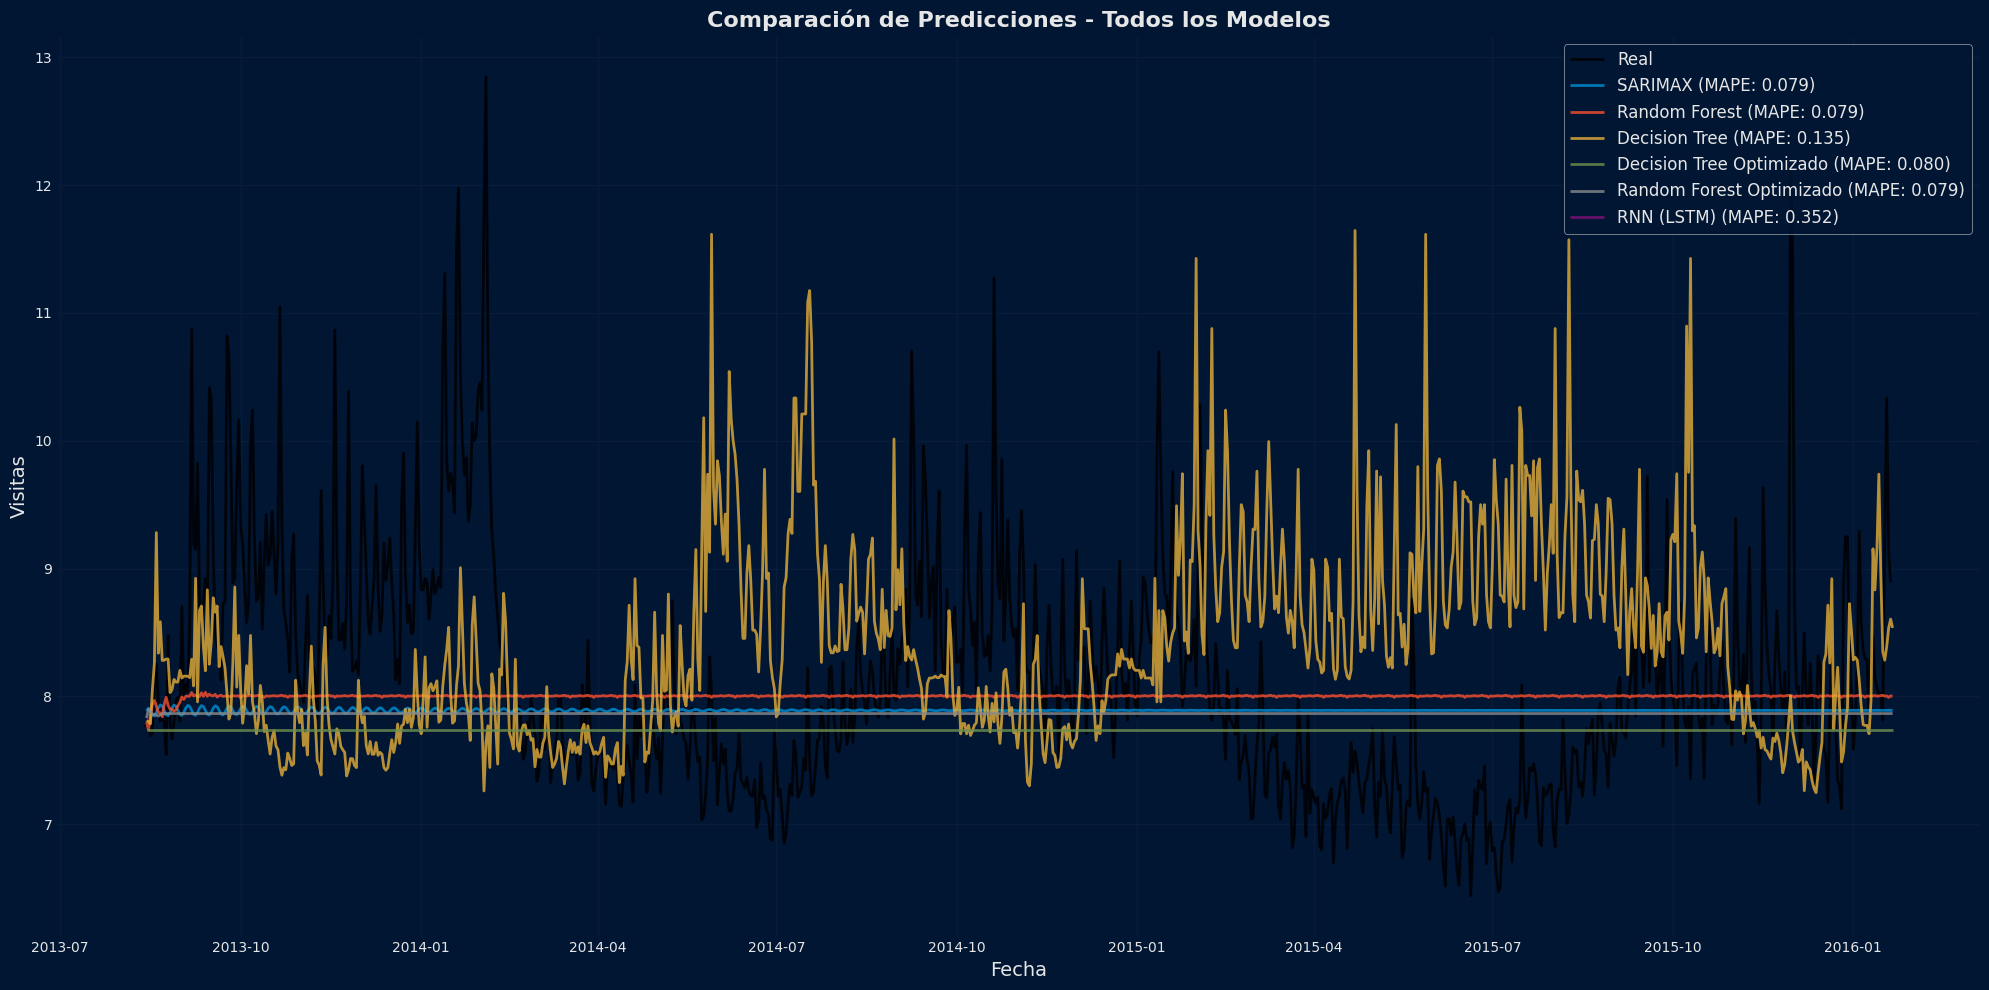

In [ ]:
# Crear la gráfica comparativa estilo la imagen de referencia
plt.figure(figsize=(20, 10))

# Filtrar las predicciones del RNN para que coincidan con el período de prueba
predictions_5_filtered = predictions_5.loc[end_train:]

# Plotear los datos reales
plt.plot(data_test.index, data_test.values, 
         label='Real', color='black', linewidth=2, alpha=0.8)

# Plotear las predicciones de cada modelo con sus MAPE
plt.plot(pred_sarimax.index, pred_sarimax.values, 
         label=f'SARIMAX (MAPE: {mape_sarimax:.3f})', 
         linewidth=2, alpha=0.8)

plt.plot(predictions_1.index, predictions_1.values, 
         label=f'Random Forest (MAPE: {mape_forecaster_1:.3f})', 
         linewidth=2, alpha=0.8)

plt.plot(predictions_2.index, predictions_2.values, 
         label=f'Decision Tree (MAPE: {mape_forecaster_2:.3f})', 
         linewidth=2, alpha=0.8)

plt.plot(predictions_3.index, predictions_3.values, 
         label=f'Decision Tree Optimizado (MAPE: {mape_forecaster_3:.3f})', 
         linewidth=2, alpha=0.8)

plt.plot(predictions_4.index, predictions_4.values, 
         label=f'Random Forest Optimizado (MAPE: {mape_forecaster_4:.3f})', 
         linewidth=2, alpha=0.8)

# Para RNN, usar solo las predicciones desde end_train
plt.plot(predictions_5_filtered.index, predictions_5_filtered['pred'].values, 
         label=f'RNN (LSTM) (MAPE: {mape_forecaster_5.iloc[0]:.3f})', 
         linewidth=2, alpha=0.8)

plt.xlabel('Fecha', fontsize=14)
plt.ylabel('Visitas', fontsize=14)
plt.title('Comparación de Predicciones - Todos los Modelos', 
          fontsize=16, fontweight='bold')
plt.legend(loc='upper right', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()